# 埃斯顿（002747.SZ）技术指标计算

本 Notebook 使用埃斯顿的日线数据，逐步计算四个核心技术指标：**RSI、MACD、布林带、VWAP**。

**设计原则：**
- 手写公式，不使用 talib 黑箱调用
- 每个计算步骤分步展示，逻辑透明可审计
- 每个指标计算完成后立即可视化
- 遵循 A 股惯例（EMA 用 adjust=False、MACD 柱乘2、RSI 用 Wilder 平滑）

**数据区间：** 2025-07-03 ~ 2026-07-03，共 242 个交易日
**数据已验证：** 无除权除息事件，无需复权

## 一、环境准备与数据加载

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm

# 显式注册中文字体（解决首次执行时的字体缓存问题）
chinese_fonts = [
    '/Library/Fonts/Arial Unicode.ttf',
    '/System/Library/Fonts/PingFang.ttc',
    '/System/Library/Fonts/STHeiti Medium.ttc',
    '/System/Library/Fonts/Supplemental/Songti.ttc',
    '/System/Library/Fonts/Hiragino Sans GB.ttc',
]
for font_path in chinese_fonts:
    try:
        fm.fontManager.addfont(font_path)
    except Exception:
        pass

# 设置绘图风格（注意：必须在字体设置之前调用 style.use，否则会重置）
plt.style.use('seaborn-v0_8-whitegrid')

# 关键：字体设置必须在 style.use 之后，否则会被样式覆盖
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 'Songti SC', 'Hiragino Sans GB', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

# 验证字体设置生效
print("font.sans-serif:", plt.rcParams['font.sans-serif'])
print("环境准备完成")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")

font.sans-serif: ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 'Songti SC', 'Hiragino Sans GB', 'DejaVu Sans']
环境准备完成
pandas: 3.0.3
numpy: 2.5.0
matplotlib: 3.11.0


In [2]:
# 读取埃斯顿日线数据
df = pd.read_csv('../data/estun_daily.csv', dtype={'trade_date': str})

# 转换日期格式并设为索引
df['date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df.set_index('date', inplace=True)

print(f"数据量: {len(df)} 个交易日")
print(f"时间范围: {df.index[0].strftime('%Y-%m-%d')} ~ {df.index[-1].strftime('%Y-%m-%d')}")
print()
df.head()

数据量: 243 个交易日
时间范围: 2025-07-03 ~ 2026-07-03



,trade_date,open,high,low,close,pre_close,pct_chg,vol,amount,pe_ttm,pb,turnover_rate,total_mv,circ_mv
date,,,,,,,,,,,,,,
2025-07-03,20250703,19.80,20.05,19.71,19.92,19.89,0.1508,98638.01,195968.315,NaN,9.4296,1.2607,1.727101e+06,1.558551e+06
2025-07-04,20250704,19.89,19.90,19.50,19.67,19.92,-1.2550,116484.02,229364.331,NaN,9.3113,1.4888,1.705425e+06,1.538991e+06
2025-07-07,20250707,19.61,19.67,19.33,19.37,19.67,-1.5252,95763.03,185913.384,NaN,9.1692,1.2240,1.679415e+06,1.515519e+06
2025-07-08,20250708,19.37,19.90,19.35,19.86,19.37,2.5297,137818.09,271772.394,NaN,9.4012,1.7615,1.721899e+06,1.553857e+06
2025-07-09,20250709,19.97,20.22,19.73,19.77,19.86,-0.4532,147411.94,294630.772,NaN,9.3586,1.8841,1.714095e+06,1.546815e+06


**数据概览：**

| 字段 | 含义 | 本任务使用 |
|------|------|-----------|
| trade_date | 交易日期 | 索引 |
| open / high / low / close | OHLC 价格 | 核心字段 |
| vol | 成交量（手） | VWAP 权重 |
| pct_chg | 涨跌幅(%) | 参考验证 |

**已知问题：** pe_ttm 字段前 179 天缺失（73.66%），本任务不使用该字段。其余字段完整。
**跳空检查：** 10 天跳空 >3%，最大 -5.98%，均为正常波动，非除权。

---

## 二、RSI 计算（相对强弱指标）

### 2.1 计算方法说明

**公式：**
$$RSI = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\text{平均涨幅}}{\text{平均跌幅}}$$

**参数：** N = 14（标准周期）

**平滑方法：** Wilder's method（alpha = 1/N），与通达信/同花顺一致

**计算步骤：**
1. 计算每日价格变化 delta = close - close.shift(1)
2. 分离上涨 gain 和下跌 loss
3. 用 Wilder EMA 计算平均涨幅和平均跌幅
4. 计算 RS 和 RSI

In [3]:
# 步骤1：计算每日价格变化，分离上涨和下跌
delta = df['close'].diff()

gain = delta.where(delta > 0, 0)      # 下跌日涨幅记0
loss = (-delta).where(delta < 0, 0)   # 上涨日跌幅记0

# 展示前10行
rsi_df = pd.DataFrame({
    'close': df['close'],
    'delta': delta,
    'gain': gain,
    'loss': loss
})
rsi_df.head(10)

,close,delta,gain,loss
date,,,,
2025-07-03,19.92,NaN,0.00,0.00
2025-07-04,19.67,-0.25,0.00,0.25
2025-07-07,19.37,-0.30,0.00,0.30
2025-07-08,19.86,0.49,0.49,0.00
2025-07-09,19.77,-0.09,0.00,0.09
2025-07-10,19.70,-0.07,0.00,0.07
2025-07-11,20.18,0.48,0.48,0.00
2025-07-14,20.39,0.21,0.21,0.00
2025-07-15,20.58,0.19,0.19,0.00


In [4]:
# 步骤2：用 Wilder's method 计算平均涨幅和平均跌幅
# Wilder EMA: alpha = 1/N, 等价于 ewm(span=N, adjust=False) 但用 alpha=1/N
N = 14
avg_gain = gain.ewm(alpha=1/N, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/N, adjust=False).mean()

print("前15行平均涨幅/跌幅（前14天在累积中，第15天开始有效）：")
pd.DataFrame({'gain': gain, 'loss': loss, 'avg_gain': avg_gain, 'avg_loss': avg_loss}).head(15)

前15行平均涨幅/跌幅（前14天在累积中，第15天开始有效）：


,gain,loss,avg_gain,avg_loss
date,,,,
2025-07-03,0.00,0.00,0.000000,0.000000
2025-07-04,0.00,0.25,0.000000,0.017857
2025-07-07,0.00,0.30,0.000000,0.038010
2025-07-08,0.49,0.00,0.035000,0.035295
2025-07-09,0.00,0.09,0.032500,0.039203
2025-07-10,0.00,0.07,0.030179,0.041402
2025-07-11,0.48,0.00,0.062309,0.038445
2025-07-14,0.21,0.00,0.072858,0.035699
2025-07-15,0.19,0.00,0.081225,0.033149


In [5]:
# 步骤3：计算 RS 和 RSI
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

# 特殊情况处理：avg_loss = 0 时 RSI = 100
rsi = rsi.where(avg_loss > 0, 100)

# 保存到 df
df['RSI'] = rsi

print("RSI 计算结果（第15~25个交易日）：")
print(rsi.iloc[14:25].round(2))
print(f"\nRSI 统计：")
print(f"  均值: {rsi.dropna().mean():.2f}")
print(f"  最大: {rsi.dropna().max():.2f}")
print(f"  最小: {rsi.dropna().min():.2f}")
print(f"  超买天数(>70): {(rsi > 70).sum()}")
print(f"  超卖天数(<30): {(rsi < 30).sum()}")

RSI 计算结果（第15~25个交易日）：
date
2025-07-23    64.39
2025-07-24    71.94
2025-07-25    74.96
2025-07-28    69.23
2025-07-29    68.11
2025-07-30    59.08
2025-07-31    56.11
2025-08-01    56.65
2025-08-04    66.81
2025-08-05    78.67
2025-08-06    82.87
Name: close, dtype: float64

RSI 统计：
  均值: 54.04
  最大: 100.00
  最小: 0.00
  超买天数(>70): 39
  超卖天数(<30): 16


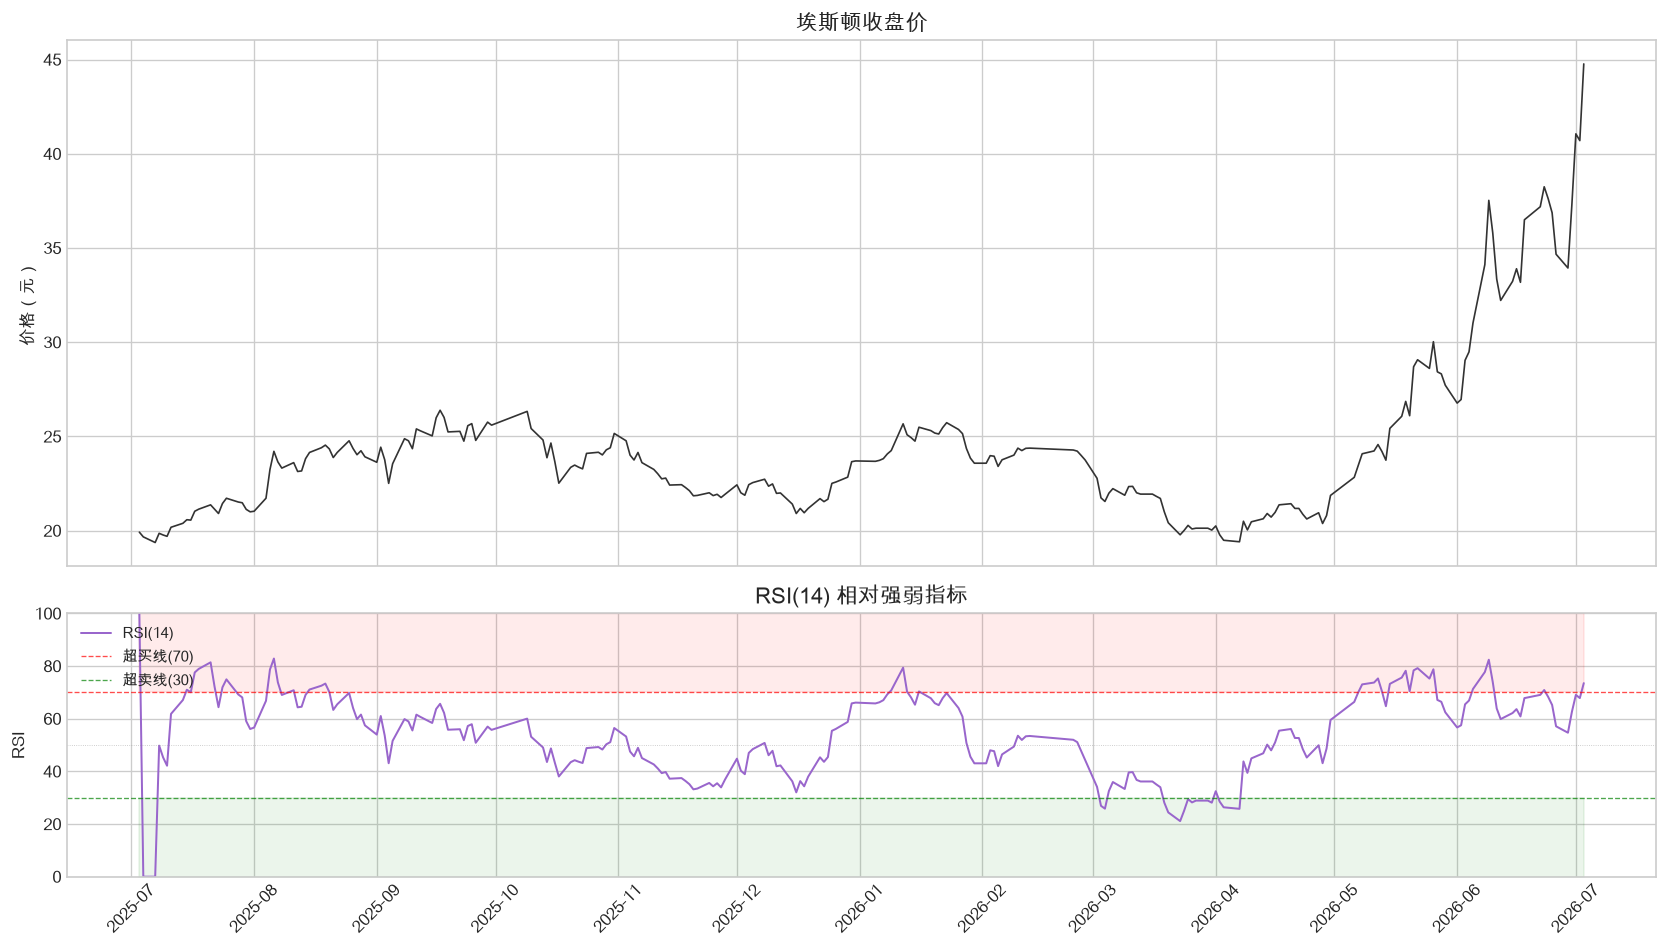

RSI 图表已生成


In [6]:
# 绘制 RSI 图表
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

# 上图：收盘价
axes[0].plot(df.index, df['close'], color='#333333', linewidth=1)
axes[0].set_title('埃斯顿收盘价', fontsize=13)
axes[0].set_ylabel('价格（元）')

# 下图：RSI
ax = axes[1]
ax.plot(df.index, df['RSI'], color='#9966cc', linewidth=1.2, label='RSI(14)')
ax.axhline(70, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='超买线(70)')
ax.axhline(30, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='超卖线(30)')
ax.axhline(50, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.fill_between(df.index, 70, 100, alpha=0.08, color='red')
ax.fill_between(df.index, 0, 30, alpha=0.08, color='green')
ax.set_title('RSI(14) 相对强弱指标', fontsize=13)
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=9)

# 格式化X轴
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rsi_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("RSI 图表已生成")

### 2.2 结果解读

**超买超卖分析：**
- RSI > 70 为超买区，价格可能回调
- RSI < 30 为超卖区，价格可能反弹
- 50 为多空分界线

**背离检查：**
- 顶背离：价格创新高但 RSI 未创新高 → 上涨动能减弱
- 底背离：价格创新低但 RSI 未创新低 → 下跌动能减弱

**注意：** 在强势趋势中 RSI 会在超买区钝化，不能简单反向操作。

---

## 三、MACD 计算（指数平滑异同移动平均线）

### 3.1 计算方法说明

**公式：**
$$DIF = EMA(12) - EMA(26)$$
$$DEA = EMA(DIF, 9)$$
$$MACD_{柱} = (DIF - DEA) \times 2$$

**参数：** 快线=12，慢线=26，信号线=9

**说明：**
- EMA 使用 `adjust=False`（与 A 股软件一致），首日 EMA = 首日收盘价
- MACD 柱乘以 2 是 A 股惯例，美股原始公式不乘 2
- 零轴是 DIF 的多空分界线

In [7]:
# 步骤1：计算 12 日 EMA 和 26 日 EMA
ema_fast = df['close'].ewm(span=12, adjust=False).mean()
ema_slow = df['close'].ewm(span=26, adjust=False).mean()

print("前10行 EMA 对比：")
pd.DataFrame({
    'close': df['close'],
    'EMA12': ema_fast,
    'EMA26': ema_slow
}).head(10).round(2)

前10行 EMA 对比：


,close,EMA12,EMA26
date,,,
2025-07-03,19.92,19.92,19.92
2025-07-04,19.67,19.88,19.90
2025-07-07,19.37,19.80,19.86
2025-07-08,19.86,19.81,19.86
2025-07-09,19.77,19.81,19.86
2025-07-10,19.70,19.79,19.84
2025-07-11,20.18,19.85,19.87
2025-07-14,20.39,19.93,19.91
2025-07-15,20.58,20.03,19.96


In [8]:
# 步骤2：计算 DIF 和 DEA
dif = ema_fast - ema_slow
dea = dif.ewm(span=9, adjust=False).mean()

# 保存到 df
df['DIF'] = dif
df['DEA'] = dea

print("DIF 和 DEA 前10行：")
pd.DataFrame({'DIF': dif, 'DEA': dea}).head(10).round(4)

DIF 和 DEA 前10行：


,DIF,DEA
date,,
2025-07-03,0.0000,0.0000
2025-07-04,-0.0199,-0.0040
2025-07-07,-0.0593,-0.0150
2025-07-08,-0.0503,-0.0221
2025-07-09,-0.0499,-0.0277
2025-07-10,-0.0546,-0.0331
2025-07-11,-0.0194,-0.0303
2025-07-14,0.0252,-0.0192
2025-07-15,0.0750,-0.0004


In [9]:
# 步骤3：计算 MACD 柱（A股惯例乘以2）
macd_hist = (dif - dea) * 2

df['MACD_hist'] = macd_hist

print("MACD 计算结果（第27~37个交易日，EMA26需要26天预热）：")
pd.DataFrame({
    'close': df['close'],
    'DIF': dif,
    'DEA': dea,
    'MACD_hist': macd_hist
}).iloc[26:37].round(4)

# 统计金叉死叉
golden_cross = ((dif.shift(1) < dea.shift(1)) & (dif > dea))
death_cross = ((dif.shift(1) > dea.shift(1)) & (dif < dea))

print(f"\n金叉次数: {golden_cross.sum()}")
print(f"死叉次数: {death_cross.sum()}")
print(f"金叉日期: {df.index[golden_cross].strftime('%Y-%m-%d').tolist()}")
print(f"死叉日期: {df.index[death_cross].strftime('%Y-%m-%d').tolist()}")

MACD 计算结果（第27~37个交易日，EMA26需要26天预热）：

金叉次数: 9
死叉次数: 8
金叉日期: ['2025-07-11', '2025-08-04', '2025-09-11', '2025-10-30', '2025-12-01', '2025-12-23', '2026-04-08', '2026-06-05', '2026-07-01']
死叉日期: ['2025-08-01', '2025-08-26', '2025-09-23', '2025-11-07', '2025-12-16', '2026-01-27', '2026-06-01', '2026-06-26']


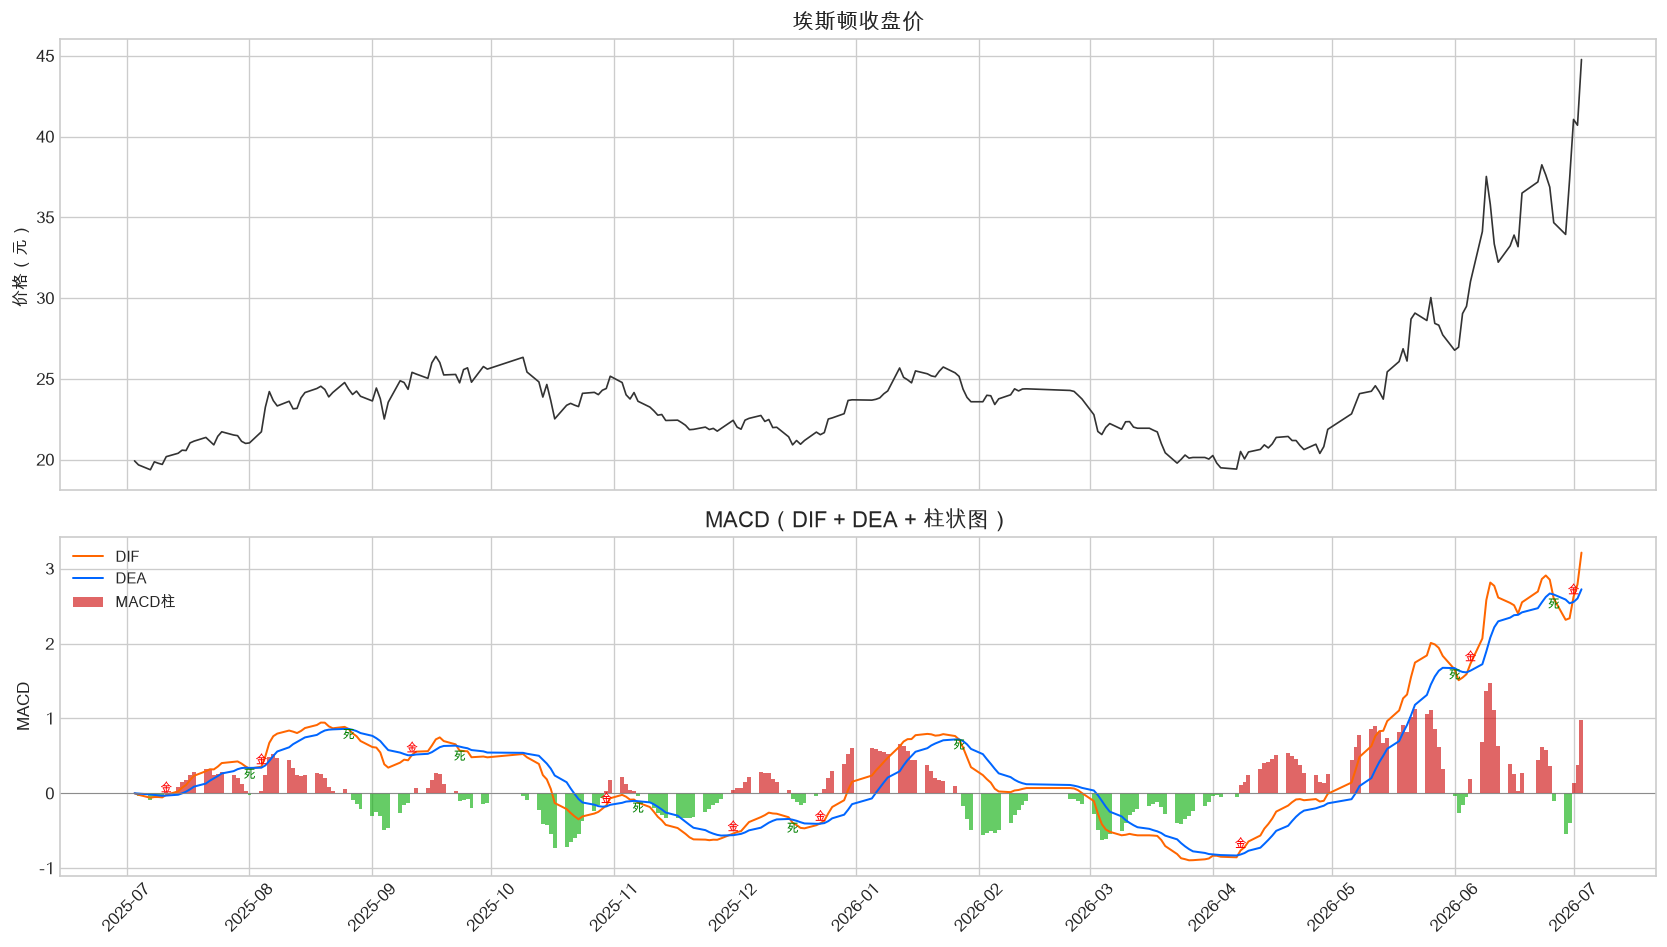

MACD 图表已生成


In [10]:
# 绘制 MACD 图表
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1.5], sharex=True)

# 上图：收盘价
axes[0].plot(df.index, df['close'], color='#333333', linewidth=1)
axes[0].set_title('埃斯顿收盘价', fontsize=13)
axes[0].set_ylabel('价格（元）')

# 下图：MACD
ax = axes[1]
# MACD 柱状图（红绿双色）
colors = ['#cc0000' if v >= 0 else '#00aa00' for v in macd_hist]
ax.bar(df.index, macd_hist, color=colors, width=1, alpha=0.6, label='MACD柱')
# DIF 和 DEA 线
ax.plot(df.index, dif, color='#ff6600', linewidth=1.2, label='DIF')
ax.plot(df.index, dea, color='#0066ff', linewidth=1.2, label='DEA')
ax.axhline(0, color='gray', linewidth=0.5)

# 标注金叉死叉
for idx in df.index[golden_cross]:
    ax.annotate('金', xy=(idx, dif[idx]), fontsize=7, color='red',
                ha='center', va='bottom')
for idx in df.index[death_cross]:
    ax.annotate('死', xy=(idx, dif[idx]), fontsize=7, color='green',
                ha='center', va='top')

ax.set_title('MACD（DIF + DEA + 柱状图）', fontsize=13)
ax.set_ylabel('MACD')
ax.legend(loc='upper left', fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('macd_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("MACD 图表已生成")

### 3.2 结果解读

**金叉死叉统计：**
- 金叉（DIF 上穿 DEA）→ 买入信号
- 死叉（DIF 下穿 DEA）→ 卖出信号
- 零轴上方金叉比零轴下方金叉更可靠

**趋势分析：**
- DIF > 0 → 多头环境
- DIF < 0 → 空头环境
- MACD 柱由负转正 → 多头力量增强

**注意：** MACD 是滞后指标，震荡市中假信号较多，更适合趋势行情。

---

## 四、布林带计算（Bollinger Bands）

### 4.1 计算方法说明

**公式：**
$$中轨 = MA(20), \quad 上轨 = 中轨 + 2\sigma, \quad 下轨 = 中轨 - 2\sigma$$
$$带宽 = \frac{上轨 - 下轨}{中轨}, \quad \%B = \frac{close - 下轨}{上轨 - 下轨}$$

**参数：** 周期 N=20，标准差倍数=2

**说明：**
- 中轨是 20 日简单移动平均
- 上下轨用标准差衡量波动区间
- 带宽收窄 → 即将变盘
- %B > 1 表示突破上轨，%B < 0 表示突破下轨

In [11]:
# 步骤1：计算中轨（20日简单移动平均）
N_bb = 20
middle_band = df['close'].rolling(window=N_bb).mean()

print("中轨前25行（前19天为NaN）：")
middle_band.head(25).round(2)

中轨前25行（前19天为NaN）：


date
2025-07-03      NaN
2025-07-04      NaN
2025-07-07      NaN
2025-07-08      NaN
2025-07-09      NaN
2025-07-10      NaN
2025-07-11      NaN
2025-07-14      NaN
2025-07-15      NaN
2025-07-16      NaN
2025-07-17      NaN
2025-07-18      NaN
2025-07-21      NaN
2025-07-22      NaN
2025-07-23      NaN
2025-07-24      NaN
2025-07-25      NaN
2025-07-28      NaN
2025-07-29      NaN
2025-07-30    20.64
2025-07-31    20.70
2025-08-01    20.77
2025-08-04    20.88
2025-08-05    21.05
2025-08-06    21.27
Name: close, dtype: float64

In [12]:
# 步骤2：计算标准差和上下轨
std = df['close'].rolling(window=N_bb).std()
upper_band = middle_band + 2 * std
lower_band = middle_band - 2 * std

# 保存到 df
df['BB_middle'] = middle_band
df['BB_upper'] = upper_band
df['BB_lower'] = lower_band

print("布林带计算结果（第20~30个交易日）：")
pd.DataFrame({
    'close': df['close'],
    '中轨': middle_band,
    '上轨': upper_band,
    '下轨': lower_band,
    '标准差': std
}).iloc[19:30].round(2)

布林带计算结果（第20~30个交易日）：


,close,中轨,上轨,下轨,标准差
date,,,,,
2025-07-30,21.13,20.64,22.12,19.17,0.74
2025-07-31,21.00,20.70,22.14,19.25,0.72
2025-08-01,21.03,20.77,22.13,19.40,0.68
2025-08-04,21.72,20.88,22.15,19.62,0.63
2025-08-05,23.24,21.05,22.61,19.50,0.78
2025-08-06,24.21,21.27,23.27,19.28,1.00
2025-08-07,23.65,21.47,23.59,19.36,1.06
2025-08-08,23.32,21.63,23.80,19.45,1.09
2025-08-11,23.61,21.79,24.05,19.53,1.13


In [13]:
# 步骤3：计算带宽和 %B
bandwidth = (upper_band - lower_band) / middle_band
percent_b = (df['close'] - lower_band) / (upper_band - lower_band)

df['BB_bandwidth'] = bandwidth
df['BB_pctB'] = percent_b

print("带宽和%B统计：")
print(f"  带宽均值: {bandwidth.dropna().mean():.4f}")
print(f"  带宽最大: {bandwidth.dropna().max():.4f}")
print(f"  带宽最小: {bandwidth.dropna().min():.4f}")
print(f"  %B > 1天数(突破上轨): {(percent_b > 1).sum()}")
print(f"  %B < 0天数(突破下轨): {(percent_b < 0).sum()}")

# 识别收口区间（带宽低于近60日均值的80%）
bw_ma60 = bandwidth.rolling(60).mean()
squeeze = bandwidth < bw_ma60 * 0.8
print(f"  布林带收口天数: {squeeze.sum()}")

带宽和%B统计：
  带宽均值: 0.1888
  带宽最大: 0.4817
  带宽最小: 0.0521
  %B > 1天数(突破上轨): 19
  %B < 0天数(突破下轨): 10
  布林带收口天数: 36


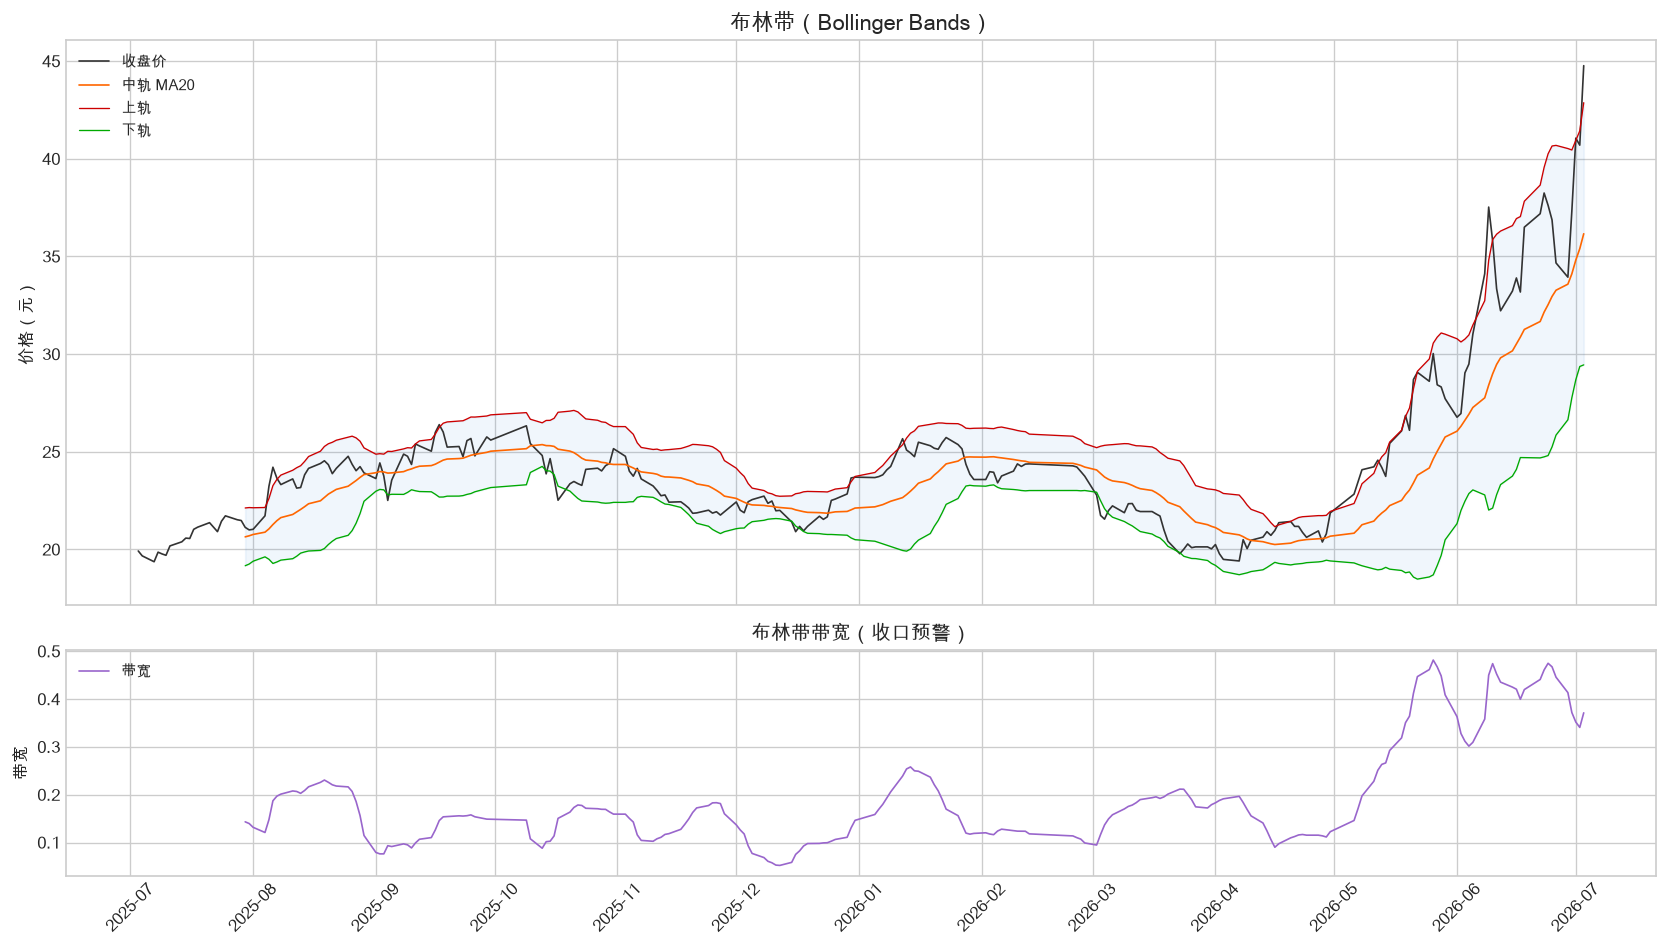

布林带图表已生成


In [14]:
# 绘制布林带图表
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2.5, 1], sharex=True)

# 上图：价格 + 布林带
ax = axes[0]
ax.plot(df.index, df['close'], color='#333333', linewidth=1, label='收盘价')
ax.plot(df.index, middle_band, color='#ff6600', linewidth=1, label='中轨 MA20')
ax.plot(df.index, upper_band, color='#cc0000', linewidth=0.8, label='上轨')
ax.plot(df.index, lower_band, color='#00aa00', linewidth=0.8, label='下轨')
ax.fill_between(df.index, lower_band, upper_band, alpha=0.06, color='#0066cc')
ax.set_title('布林带（Bollinger Bands）', fontsize=13)
ax.set_ylabel('价格（元）')
ax.legend(loc='upper left', fontsize=9)

# 下图：带宽
ax2 = axes[1]
ax2.plot(df.index, bandwidth, color='#9966cc', linewidth=1, label='带宽')
ax2.set_title('布林带带宽（收口预警）', fontsize=12)
ax2.set_ylabel('带宽')
ax2.legend(loc='upper left', fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bollinger_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("布林带图表已生成")

### 4.2 结果解读

**收口识别：**
- 带宽收窄到极低水平 → 波动率被压缩，即将出现大行情
- 收口本身不指明方向，需结合其他指标判断

**超买超卖分析：**
- 价格触及/突破上轨 → 短期超买
- 价格触及/突破下轨 → 短期超卖
- %B > 1：突破上轨；%B < 0：突破下轨

**注意：** 强势趋势中价格会沿轨道运行较长时间，"触及上轨=超买"逻辑可能失效。

---

## 五、VWAP 计算（成交量加权均价）

### 5.1 计算方法说明

**公式：**
$$VWAP = \frac{\sum (典型价格 \times 成交量)}{\sum 成交量}$$
$$典型价格 = \frac{最高价 + 最低价 + 收盘价}{3}$$
$$偏离度 = \frac{close - VWAP}{VWAP} \times 100\%$$

**参数：** 滚动窗口 N=20（20日滚动 VWAP）

**说明：**
- VWAP 代表一段时间内市场的真实平均成交成本
- 成交量大的那天对 VWAP 影响更大
- 偏离度 > +3% 为超涨，< -3% 为超跌

In [15]:
# 步骤1：计算典型价格
typical_price = (df['high'] + df['low'] + df['close']) / 3
tp_vol = typical_price * df['vol']

print("典型价格前10行：")
pd.DataFrame({
    'high': df['high'],
    'low': df['low'],
    'close': df['close'],
    'typical_price': typical_price,
    'vol': df['vol'],
    'tp_x_vol': tp_vol
}).head(10).round(2)

典型价格前10行：


,high,low,close,typical_price,vol,tp_x_vol
date,,,,,,
2025-07-03,20.05,19.71,19.92,19.89,98638.01,1962238.81
2025-07-04,19.90,19.50,19.67,19.69,116484.02,2293570.35
2025-07-07,19.67,19.33,19.37,19.46,95763.03,1863229.35
2025-07-08,19.90,19.35,19.86,19.70,137818.09,2715475.77
2025-07-09,20.22,19.73,19.77,19.91,147411.94,2934480.35
2025-07-10,19.83,19.60,19.70,19.71,96992.14,1911715.08
2025-07-11,20.29,19.65,20.18,20.04,213771.47,4283980.26
2025-07-14,20.55,20.15,20.39,20.36,242528.06,4938679.73
2025-07-15,20.69,20.30,20.58,20.52,257934.48,5293675.31


In [16]:
# 步骤2：计算20日滚动 VWAP
N_vwap = 20
vwap = tp_vol.rolling(window=N_vwap).sum() / df['vol'].rolling(window=N_vwap).sum()

df['VWAP'] = vwap

print("VWAP 计算结果（第20~30个交易日）：")
pd.DataFrame({
    'close': df['close'],
    'VWAP': vwap,
    'typical_price': typical_price
}).iloc[19:30].round(2)

VWAP 计算结果（第20~30个交易日）：


,close,VWAP,typical_price
date,,,
2025-07-30,21.13,20.83,21.20
2025-07-31,21.00,20.86,21.13
2025-08-01,21.03,20.90,21.04
2025-08-04,21.72,20.98,21.51
2025-08-05,23.24,21.29,22.86
2025-08-06,24.21,21.69,23.83
2025-08-07,23.65,21.91,23.77
2025-08-08,23.32,22.06,23.47
2025-08-11,23.61,22.21,23.61


In [17]:
# 步骤3：计算偏离度
deviation = (df['close'] - vwap) / vwap * 100
df['VWAP_dev'] = deviation

print("VWAP 偏离度统计：")
print(f"  偏离度均值: {deviation.dropna().mean():.2f}%")
print(f"  偏离度最大: {deviation.dropna().max():.2f}%")
print(f"  偏离度最小: {deviation.dropna().min():.2f}%")
print(f"  超涨天数(>+3%): {(deviation > 3).sum()}")
print(f"  超跌天数(<-3%): {(deviation < -3).sum()}")
print(f"  价格在VWAP上方天数: {(deviation > 0).sum()} / {deviation.dropna().shape[0]}")

# 最新一天
last_date = df.index[-1]
print(f"\n最新交易日({last_date.strftime('%Y-%m-%d')})：")
print(f"  收盘价: {df['close'].iloc[-1]:.2f}")
print(f"  VWAP: {vwap.iloc[-1]:.2f}")
print(f"  偏离度: {deviation.iloc[-1]:+.2f}%")

VWAP 偏离度统计：
  偏离度均值: 1.37%
  偏离度最大: 30.48%
  偏离度最小: -11.86%
  超涨天数(>+3%): 87
  超跌天数(<-3%): 64
  价格在VWAP上方天数: 122 / 224

最新交易日(2026-07-03)：
  收盘价: 44.77
  VWAP: 36.26
  偏离度: +23.45%


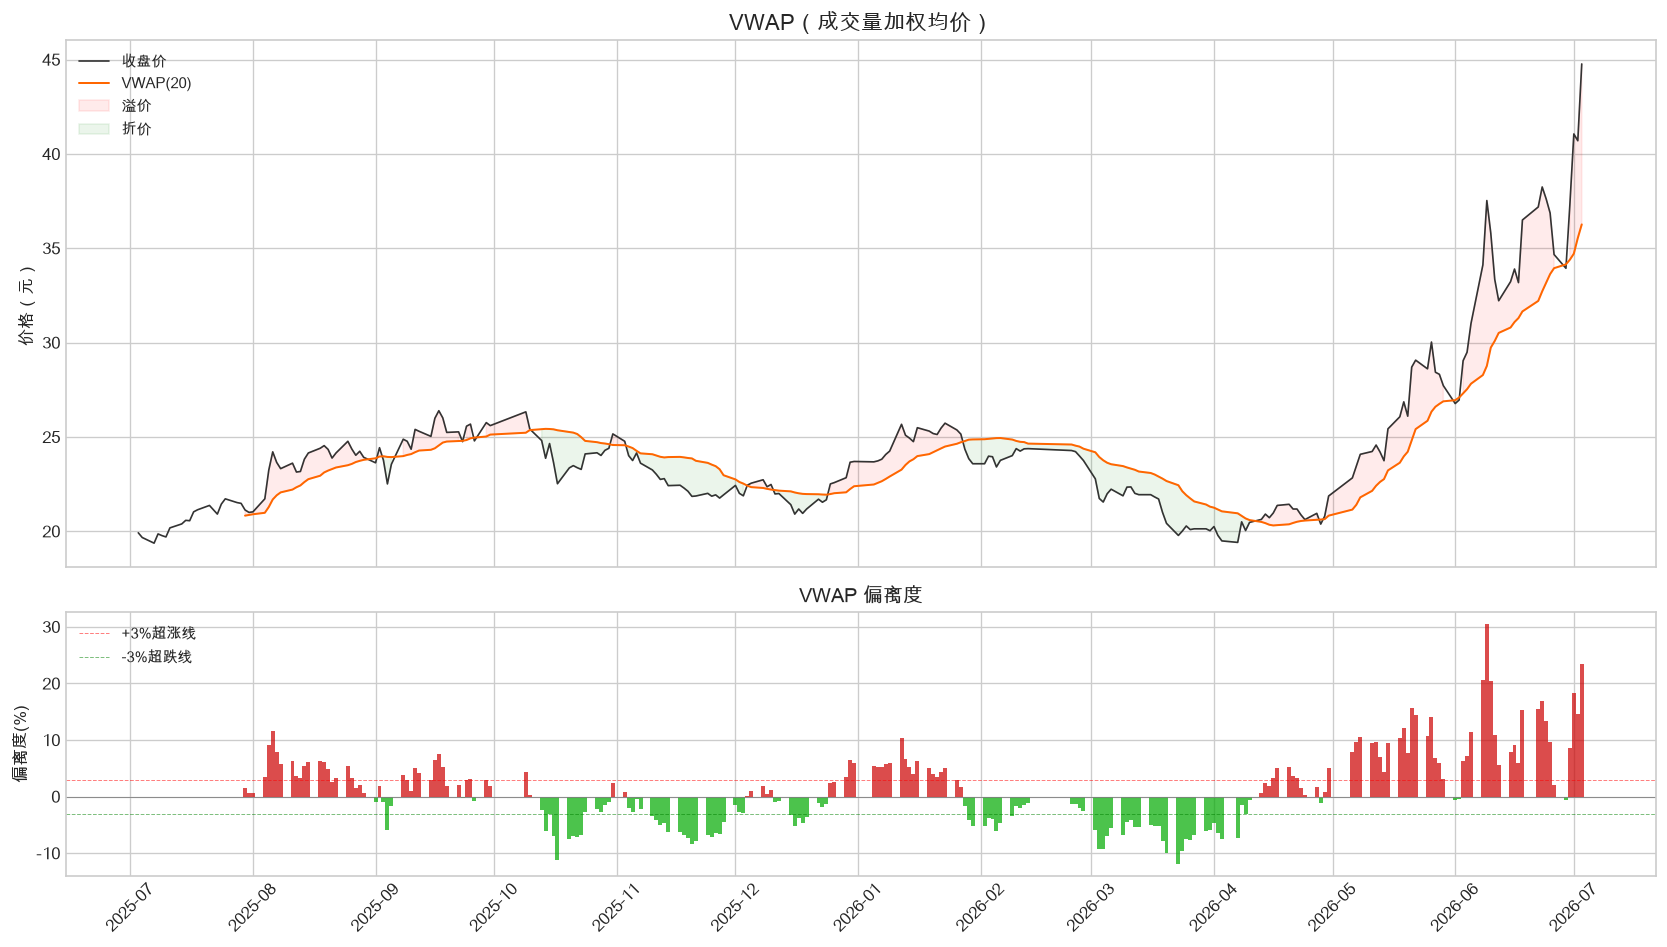

VWAP 图表已生成


In [18]:
# 绘制 VWAP 图表
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)

# 上图：价格 + VWAP
ax = axes[0]
ax.plot(df.index, df['close'], color='#333333', linewidth=1, label='收盘价')
ax.plot(df.index, vwap, color='#ff6600', linewidth=1.2, label='VWAP(20)')
ax.fill_between(df.index, vwap, df['close'],
                where=df['close'] >= vwap, alpha=0.08, color='red', label='溢价')
ax.fill_between(df.index, vwap, df['close'],
                where=df['close'] < vwap, alpha=0.08, color='green', label='折价')
ax.set_title('VWAP（成交量加权均价）', fontsize=13)
ax.set_ylabel('价格（元）')
ax.legend(loc='upper left', fontsize=9)

# 下图：偏离度柱状图
ax2 = axes[1]
dev_colors = ['#cc0000' if v >= 0 else '#00aa00' for v in deviation]
ax2.bar(df.index, deviation, color=dev_colors, width=1, alpha=0.7)
ax2.axhline(3, color='red', linestyle='--', linewidth=0.6, alpha=0.5, label='+3%超涨线')
ax2.axhline(-3, color='green', linestyle='--', linewidth=0.6, alpha=0.5, label='-3%超跌线')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_title('VWAP 偏离度', fontsize=12)
ax2.set_ylabel('偏离度(%)')
ax2.legend(loc='upper left', fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('vwap_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("VWAP 图表已生成")

### 5.2 结果解读

**支撑阻力分析：**
- VWAP 是市场平均成本线，具有天然支撑/阻力作用
- 价格在 VWAP 上方 → 偏强；下方 → 偏弱
- 价格从下方上穿 VWAP → 买入信号

**偏离度评估：**
- 偏离度 > +3% → 超涨，有回归均值压力
- 偏离度 < -3% → 超跌，可能反弹
- 偏离度过大时，VWAP 会像"磁铁"一样把价格拉回

**注意：** 强势趋势中价格可在 VWAP 上方运行很长时间，不能仅凭偏离度做空。

---

## 六、综合分析

In [19]:
# 四指标合并展示
summary = pd.DataFrame({
    'close': df['close'],
    'RSI': df['RSI'],
    'DIF': df['DIF'],
    'DEA': df['DEA'],
    'MACD_hist': df['MACD_hist'],
    'BB_upper': df['BB_upper'],
    'BB_middle': df['BB_middle'],
    'BB_lower': df['BB_lower'],
    'VWAP': df['VWAP'],
    'VWAP_dev%': df['VWAP_dev']
})

print("四指标综合数据（最后10个交易日）：")
summary.tail(10).round(2)

四指标综合数据（最后10个交易日）：


,close,RSI,DIF,DEA,MACD_hist,BB_upper,BB_middle,BB_lower,VWAP,VWAP_dev%
date,,,,,,,,,,
2026-06-22,37.19,69.07,2.70,2.47,0.44,38.65,31.67,24.69,32.21,15.46
2026-06-23,38.25,70.91,2.86,2.55,0.62,39.56,32.15,24.74,32.72,16.91
2026-06-24,37.62,68.31,2.91,2.62,0.57,40.26,32.53,24.81,33.18,13.39
2026-06-25,36.87,65.24,2.85,2.67,0.37,40.66,32.95,25.25,33.63,9.63
2026-06-26,34.67,57.13,2.60,2.66,-0.11,40.69,33.27,25.85,33.95,2.13
2026-06-29,33.94,54.70,2.32,2.59,-0.54,40.53,33.58,26.64,34.15,-0.61
2026-06-30,37.33,62.64,2.34,2.54,-0.40,40.45,34.11,27.77,34.40,8.53
2026-07-01,41.06,69.07,2.63,2.56,0.14,40.94,34.82,28.69,34.72,18.27
2026-07-02,40.70,67.86,2.79,2.60,0.38,41.43,35.40,29.37,35.54,14.51


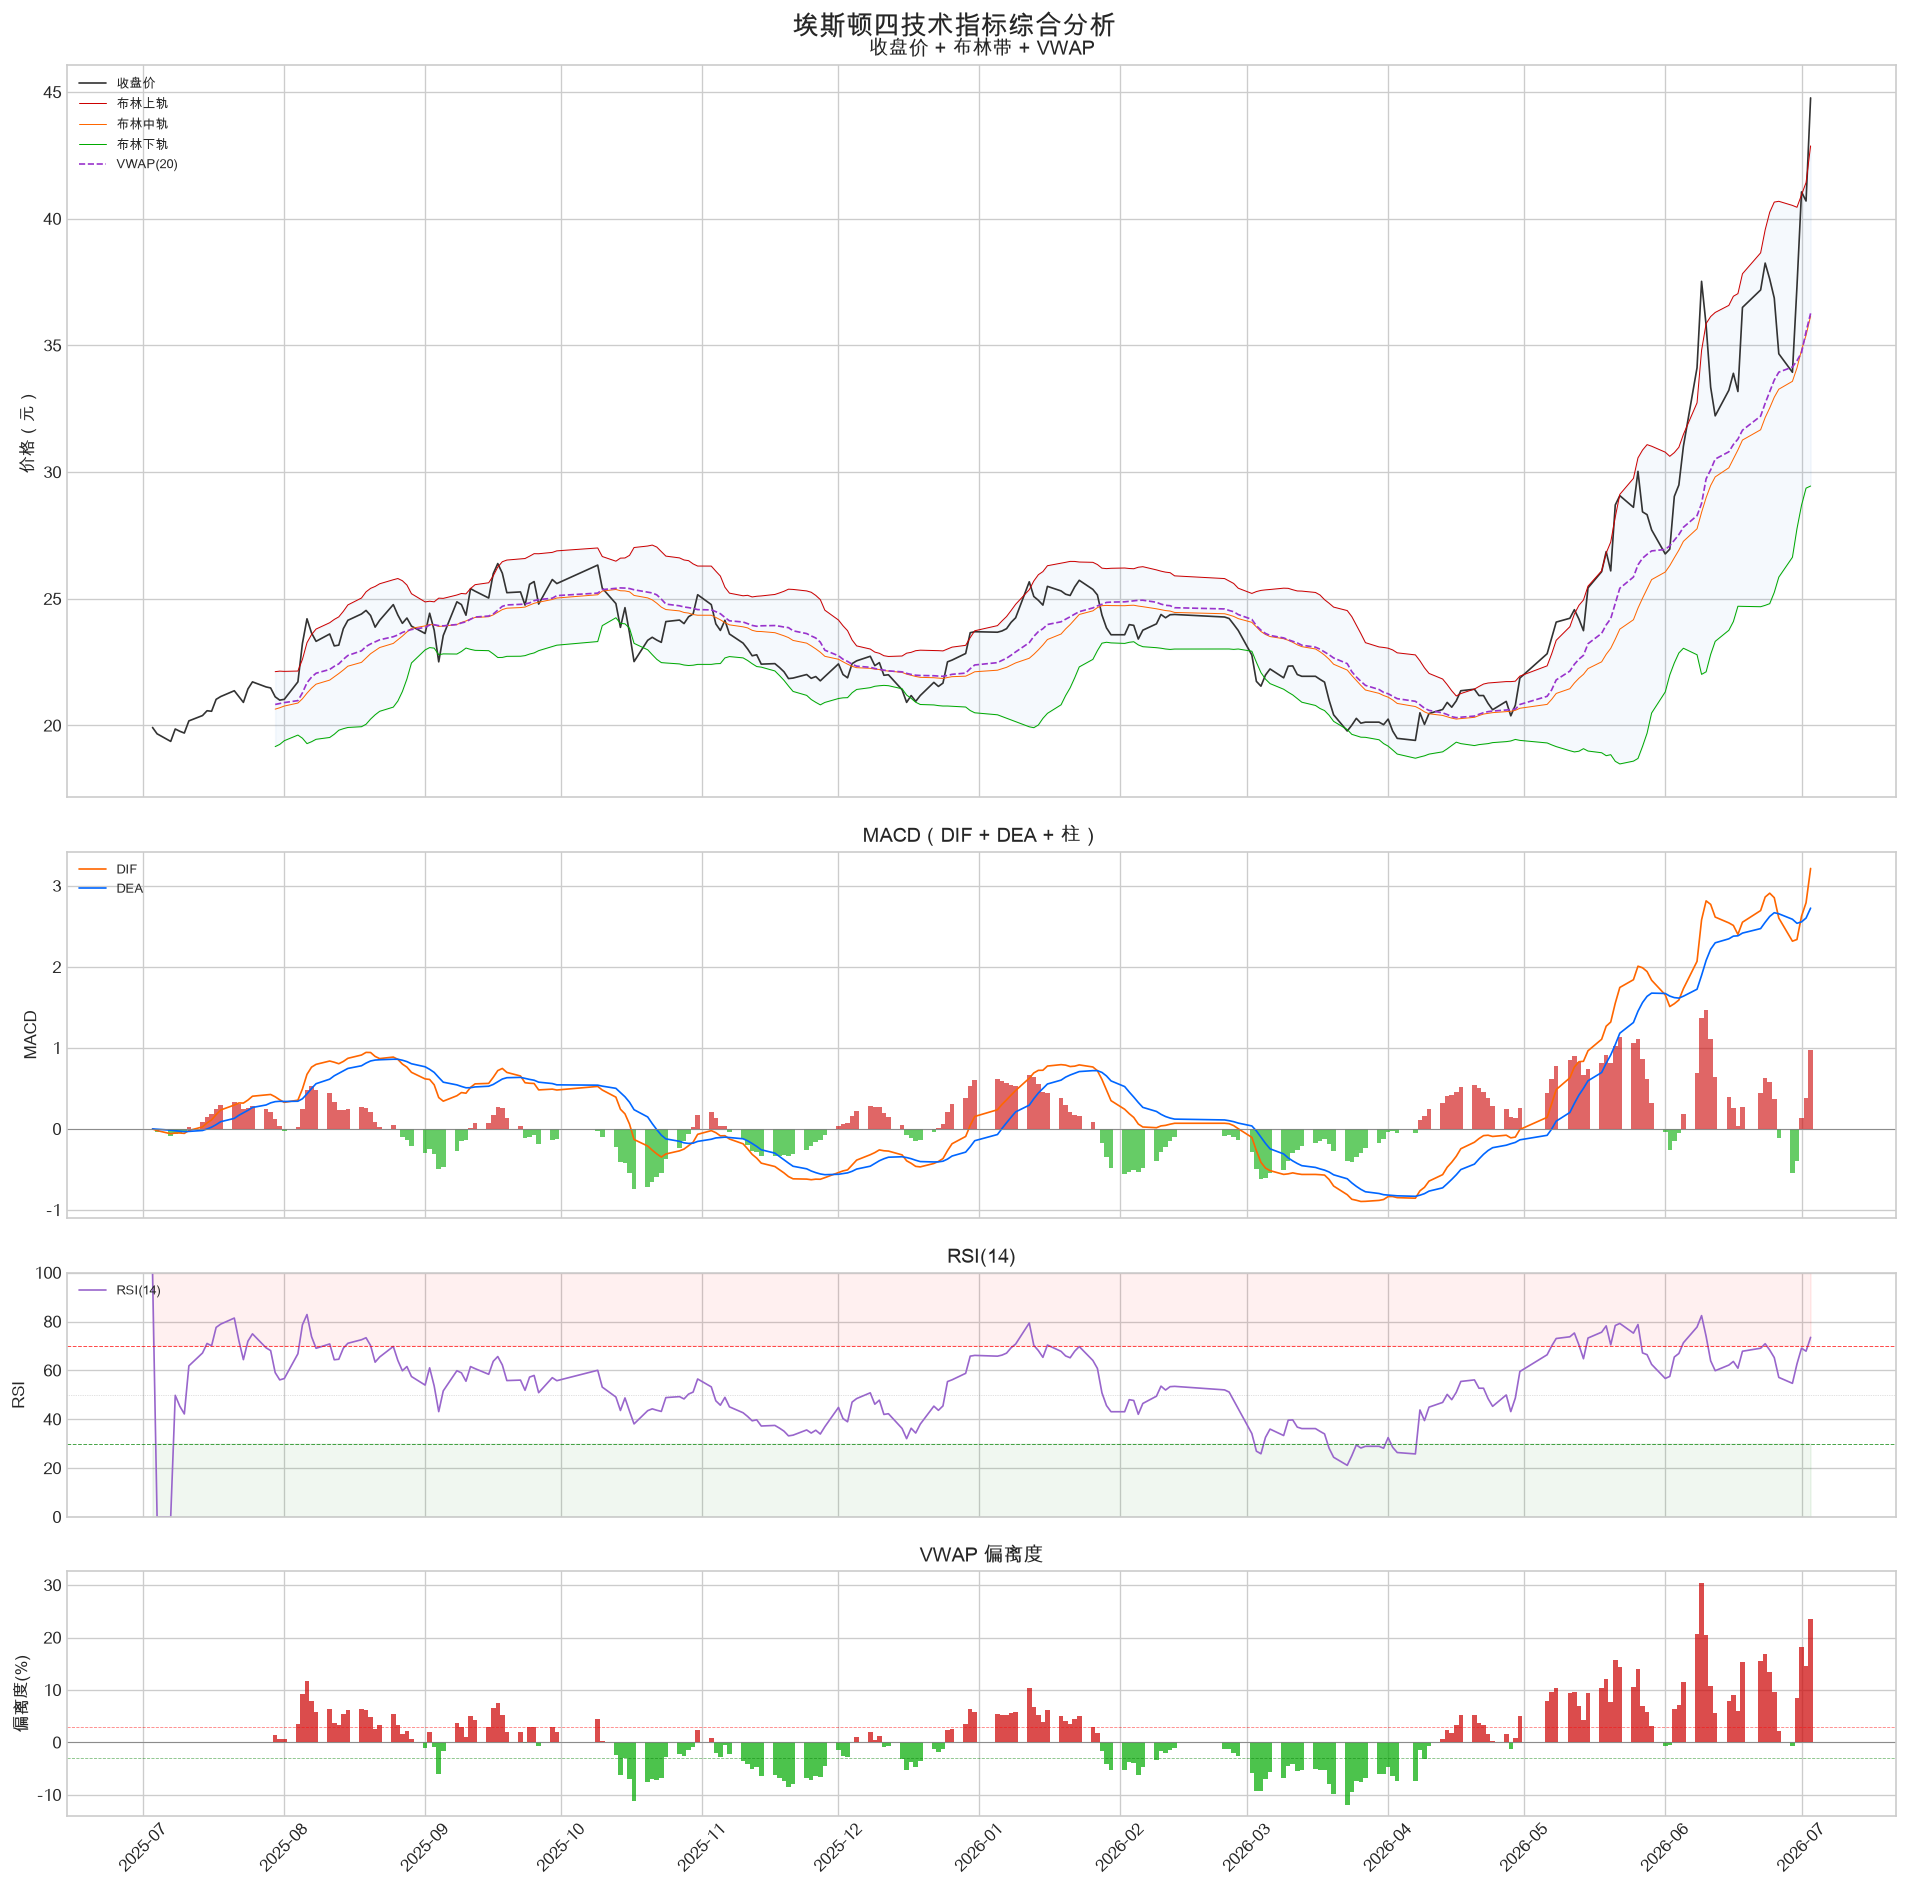

综合图表已生成


In [20]:
# 绘制综合图表：4个子图垂直排列
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True,
                         height_ratios=[3, 1.5, 1, 1])
fig.suptitle('埃斯顿四技术指标综合分析', fontsize=16, y=0.98)

# 子图1：收盘价 + 布林带 + VWAP
ax = axes[0]
ax.plot(df.index, df['close'], color='#333333', linewidth=1, label='收盘价')
ax.plot(df.index, df['BB_upper'], color='#cc0000', linewidth=0.6, label='布林上轨')
ax.plot(df.index, df['BB_middle'], color='#ff6600', linewidth=0.6, label='布林中轨')
ax.plot(df.index, df['BB_lower'], color='#00aa00', linewidth=0.6, label='布林下轨')
ax.fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.04, color='#0066cc')
ax.plot(df.index, df['VWAP'], color='#9933cc', linewidth=1, linestyle='--', label='VWAP(20)')
ax.set_ylabel('价格（元）')
ax.set_title('收盘价 + 布林带 + VWAP', fontsize=12)
ax.legend(loc='upper left', fontsize=8)

# 子图2：MACD
ax = axes[1]
colors_macd = ['#cc0000' if v >= 0 else '#00aa00' for v in df['MACD_hist']]
ax.bar(df.index, df['MACD_hist'], color=colors_macd, width=1, alpha=0.6)
ax.plot(df.index, df['DIF'], color='#ff6600', linewidth=1, label='DIF')
ax.plot(df.index, df['DEA'], color='#0066ff', linewidth=1, label='DEA')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('MACD')
ax.set_title('MACD（DIF + DEA + 柱）', fontsize=12)
ax.legend(loc='upper left', fontsize=8)

# 子图3：RSI
ax = axes[2]
ax.plot(df.index, df['RSI'], color='#9966cc', linewidth=1, label='RSI(14)')
ax.axhline(70, color='red', linestyle='--', linewidth=0.6, alpha=0.7)
ax.axhline(30, color='green', linestyle='--', linewidth=0.6, alpha=0.7)
ax.axhline(50, color='gray', linestyle=':', linewidth=0.4, alpha=0.5)
ax.fill_between(df.index, 70, 100, alpha=0.06, color='red')
ax.fill_between(df.index, 0, 30, alpha=0.06, color='green')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.set_title('RSI(14)', fontsize=12)
ax.legend(loc='upper left', fontsize=8)

# 子图4：VWAP偏离度
ax = axes[3]
dev_colors = ['#cc0000' if v >= 0 else '#00aa00' for v in df['VWAP_dev']]
ax.bar(df.index, df['VWAP_dev'], color=dev_colors, width=1, alpha=0.7)
ax.axhline(3, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axhline(-3, color='green', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('偏离度(%)')
ax.set_title('VWAP 偏离度', fontsize=12)

# 格式化X轴
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('combined_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("综合图表已生成")

### 6.1 四指标综合解读

将四个指标放在一起对照分析，可以获得更全面的市场判断：

| 指标 | 当前状态 | 信号 |
|------|---------|------|
| RSI | 待运行后查看 | 超买/超卖/中性 |
| MACD | 待运行后查看 | 金叉/死叉/零轴上下 |
| 布林带 | 待运行后查看 | 收口/开口/轨道位置 |
| VWAP | 待运行后查看 | 溢价/折价/偏离度 |

### 6.2 信号交叉验证（多指标共振）

**核心原则：单个指标信号谨慎，多个指标同时信号果断。**

| 买入共振信号 | 卖出共振信号 |
|-------------|-------------|
| MACD 金叉 + DIF在零轴上方 | MACD 死叉 + DIF在零轴下方 |
| RSI 从超卖区回升 | RSI 从超买区回落 |
| 价格上穿 VWAP | 价格下穿 VWAP |
| 价格触及布林带下轨 | 价格触及布林带上轨 |

**三重确认示例：** MACD 金叉 + RSI < 50 且回升 + 价格上穿 VWAP → 强买入信号

运行完 Notebook 后，可以对照上面的表格，检查最近几个交易日是否有共振信号。

---

## 七、结论与备注

### 计算方法总结

| 指标 | 核心公式 | 关键参数 | A股特殊处理 |
|------|---------|---------|------------|
| RSI | 100 - 100/(1+RS) | N=14 | Wilder平滑(alpha=1/N) |
| MACD | DIF=EMA12-EMA26 | 12/26/9 | 柱乘2，EMA用adjust=False |
| 布林带 | 中轨±2σ | N=20, 2σ | 无 |
| VWAP | Σ(典型价格×量)/Σ量 | N=20 | 典型价格=(H+L+C)/3 |

### 注意事项

1. **不复权处理**：已验证数据区间内 adj_factor 恒为 6.213，无除权除息
2. **EMA初始值**：使用 adjust=False，首日 EMA = 首日收盘价
3. **RSI平滑**：使用 Wilder's method，与通达信/同花顺一致
4. **MACD柱乘2**：遵循 A 股惯例
5. **NaN处理**：前 N-1 天因数据不足产生 NaN，属正常现象
6. **成交量单位**：vol 字段单位为"手"，不影响 VWAP 计算（加权比例不变）

---

*本 Notebook 由 spec.md 规格说明书驱动生成，所有指标均从公式手写实现，无黑箱调用。*